In [1]:
import os
import sys
from os.path import join

arch_dir = '/jet/home/xwang30/kl-nn/arch'

if arch_dir not in sys.path:
    sys.path.insert(0, arch_dir)
    
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import torch
from torch.utils.data import DataLoader, Subset
import pyxis.torch as pxt
import pyxis as px
import galsim as gs

import config
from utils import img_to_gal_axis

stem = 'CNN-CNN-flow'
data_dir = '/ocean/projects/phy250048p/shared/datasets/train_100k_mirror/'
samp_dir = '/ocean/projects/phy250048p/shared/samples/samples_train_100k_mirror.csv'
fig_dir = '/ocean/projects/phy250048p/shared/figures/'
model_dir = f'/ocean/projects/phy250048p/shared/models/{stem}/'
loss_dir = '/ocean/projects/phy250048p/shared/models/losses/'
results_dir = '/ocean/projects/phy250048p/shared/results/'
cache_dir = '/ocean/projects/phy250048p/shared/cache/'

In [2]:
plt.rcParams.update({"text.usetex": False, "font.family": "serif", "figure.dpi": 300})
os.makedirs(join(fig_dir, stem), exist_ok=True)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
# Get data loader
bs = 1000
test_args = list(config.test.values())
test_ds = pxt.TorchDataset(data_dir)
test_dl = DataLoader(test_ds,
                     batch_size=bs,
                     pin_memory=False,
                     shuffle=False,)
nsub = 100000
# sub_idx = np.delete(np.arange(0, nsub), np.arange(0, nsub, 10))
sub_idx = np.arange(0, nsub)
subset = Subset(test_ds, sub_idx)
sub_dl = DataLoader(subset,
                    batch_size=bs,
                    pin_memory=False,
                    shuffle=False,)

In [5]:
snrs = torch.rand((nsub,), device=device)*995 + 5
stacked_img = torch.zeros_like(test_ds[0]['img'], device=device)
for i, batch in enumerate(sub_dl):
    # stacked_img += torch.sum(apply_noise(batch['img'].float().to(device), snrs[i], device=device), dim=0)
    stacked_img += torch.sum(batch['img'].float().to(device), dim=0)
stacked_img = stacked_img.cpu().numpy()[0]
stacked_img /= np.max(stacked_img)

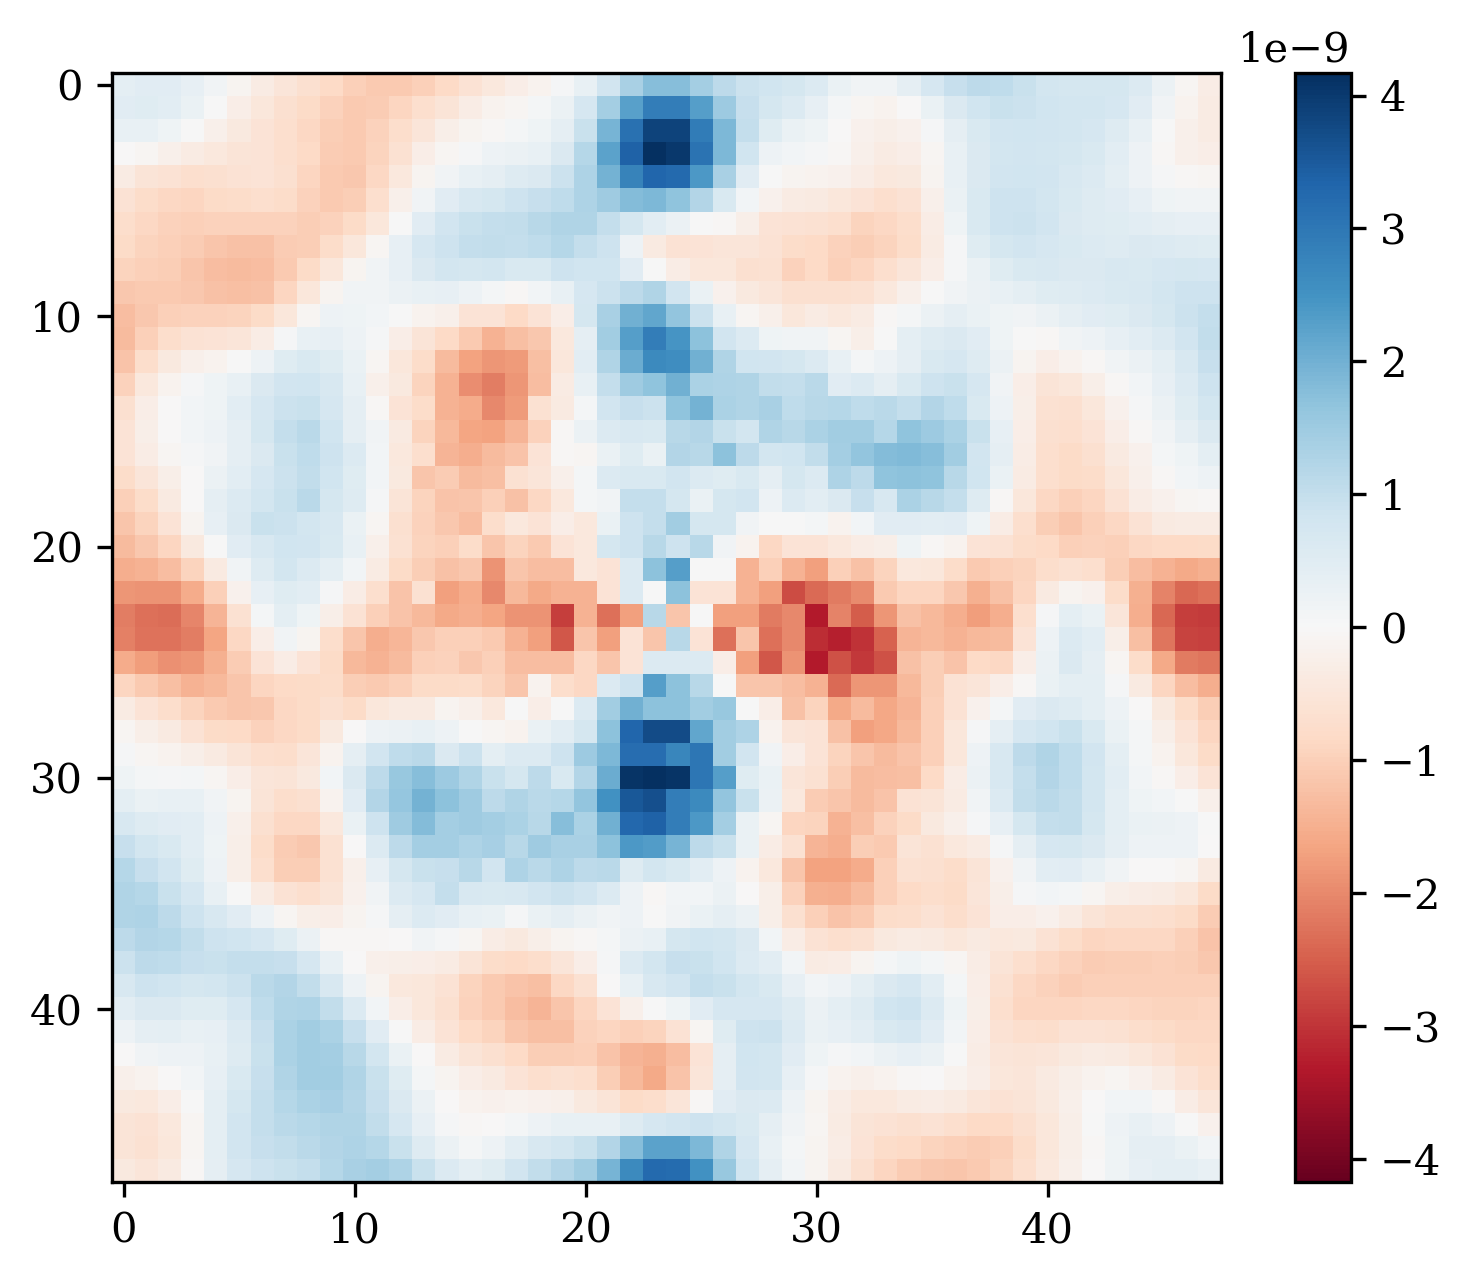

In [6]:
stacked_img_rot90 = np.rot90(stacked_img)
diff_img_90 = stacked_img - stacked_img_rot90
plt.imshow(diff_img_90, cmap='RdBu', norm=colors.CenteredNorm())
plt.colorbar()
plt.savefig(join(fig_dir, stem, 'stacked_img_diff_90_train_100k_mirror.png'))
plt.show()

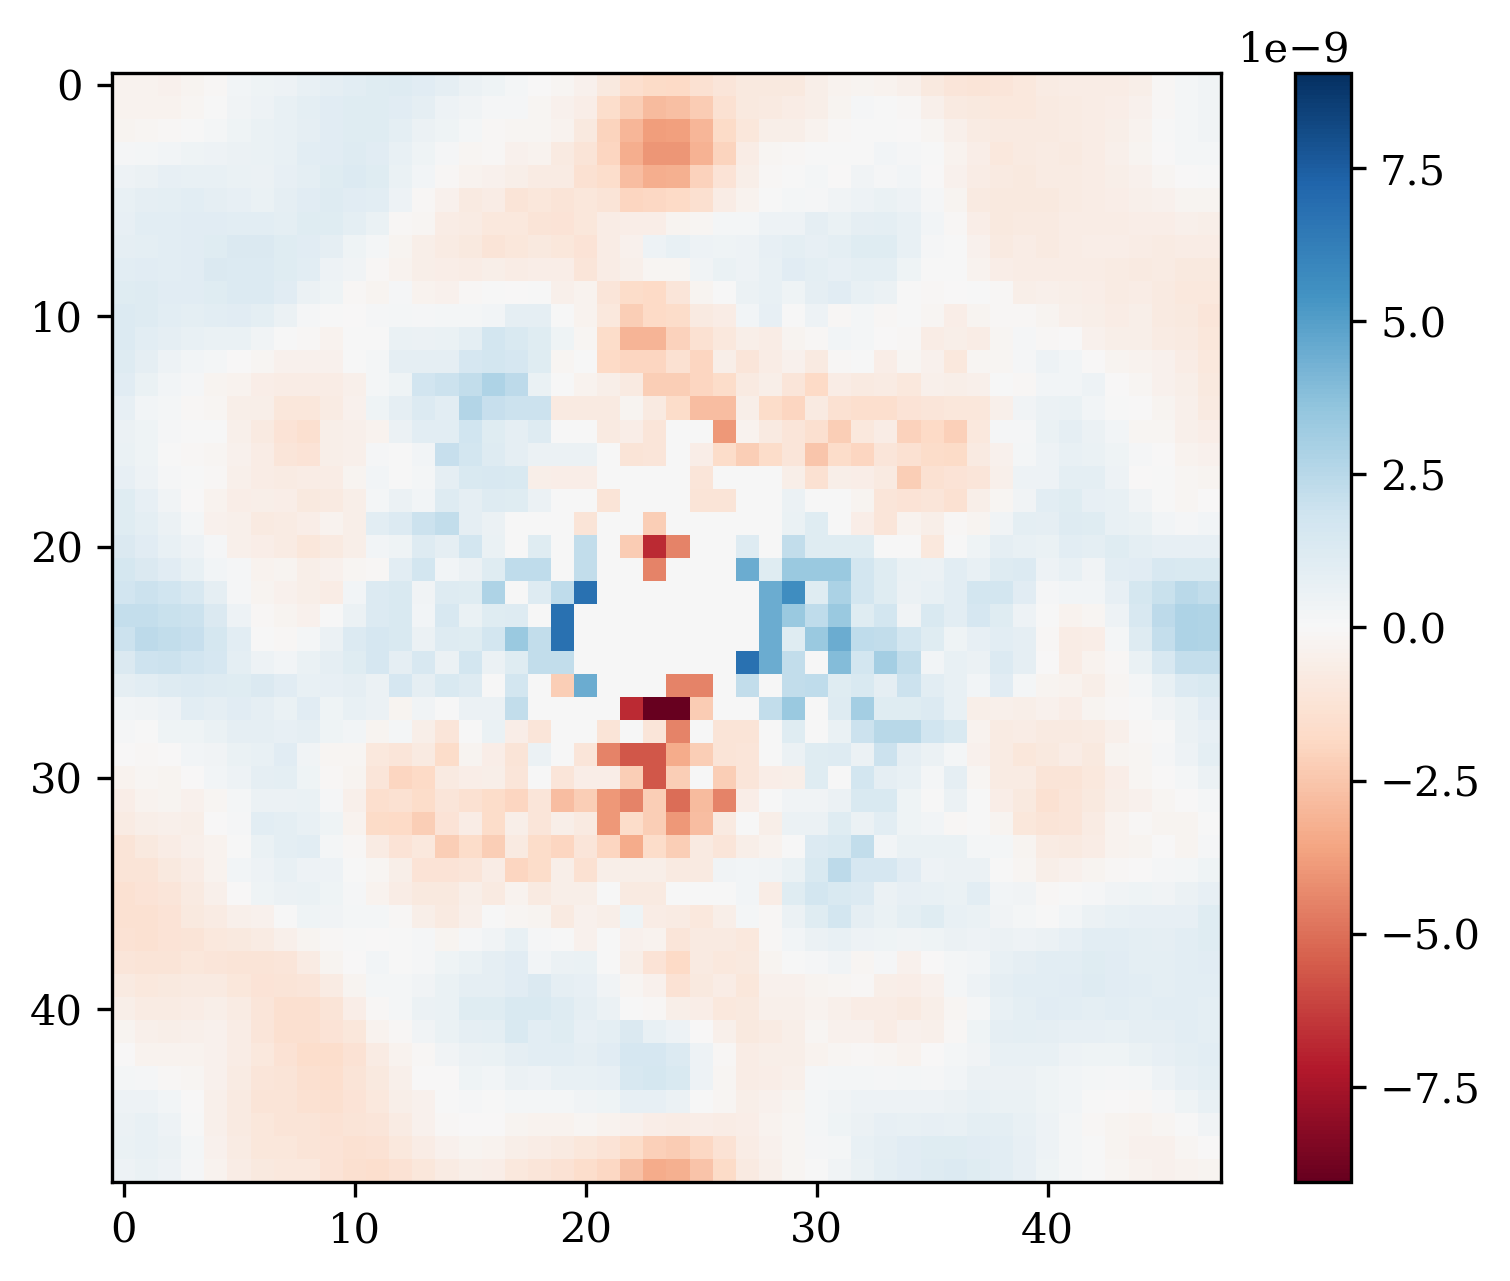

In [19]:
plt.imshow(stacked_img_rot90 - stacked_img, cmap='RdBu', norm=colors.CenteredNorm())
plt.colorbar()
plt.show()

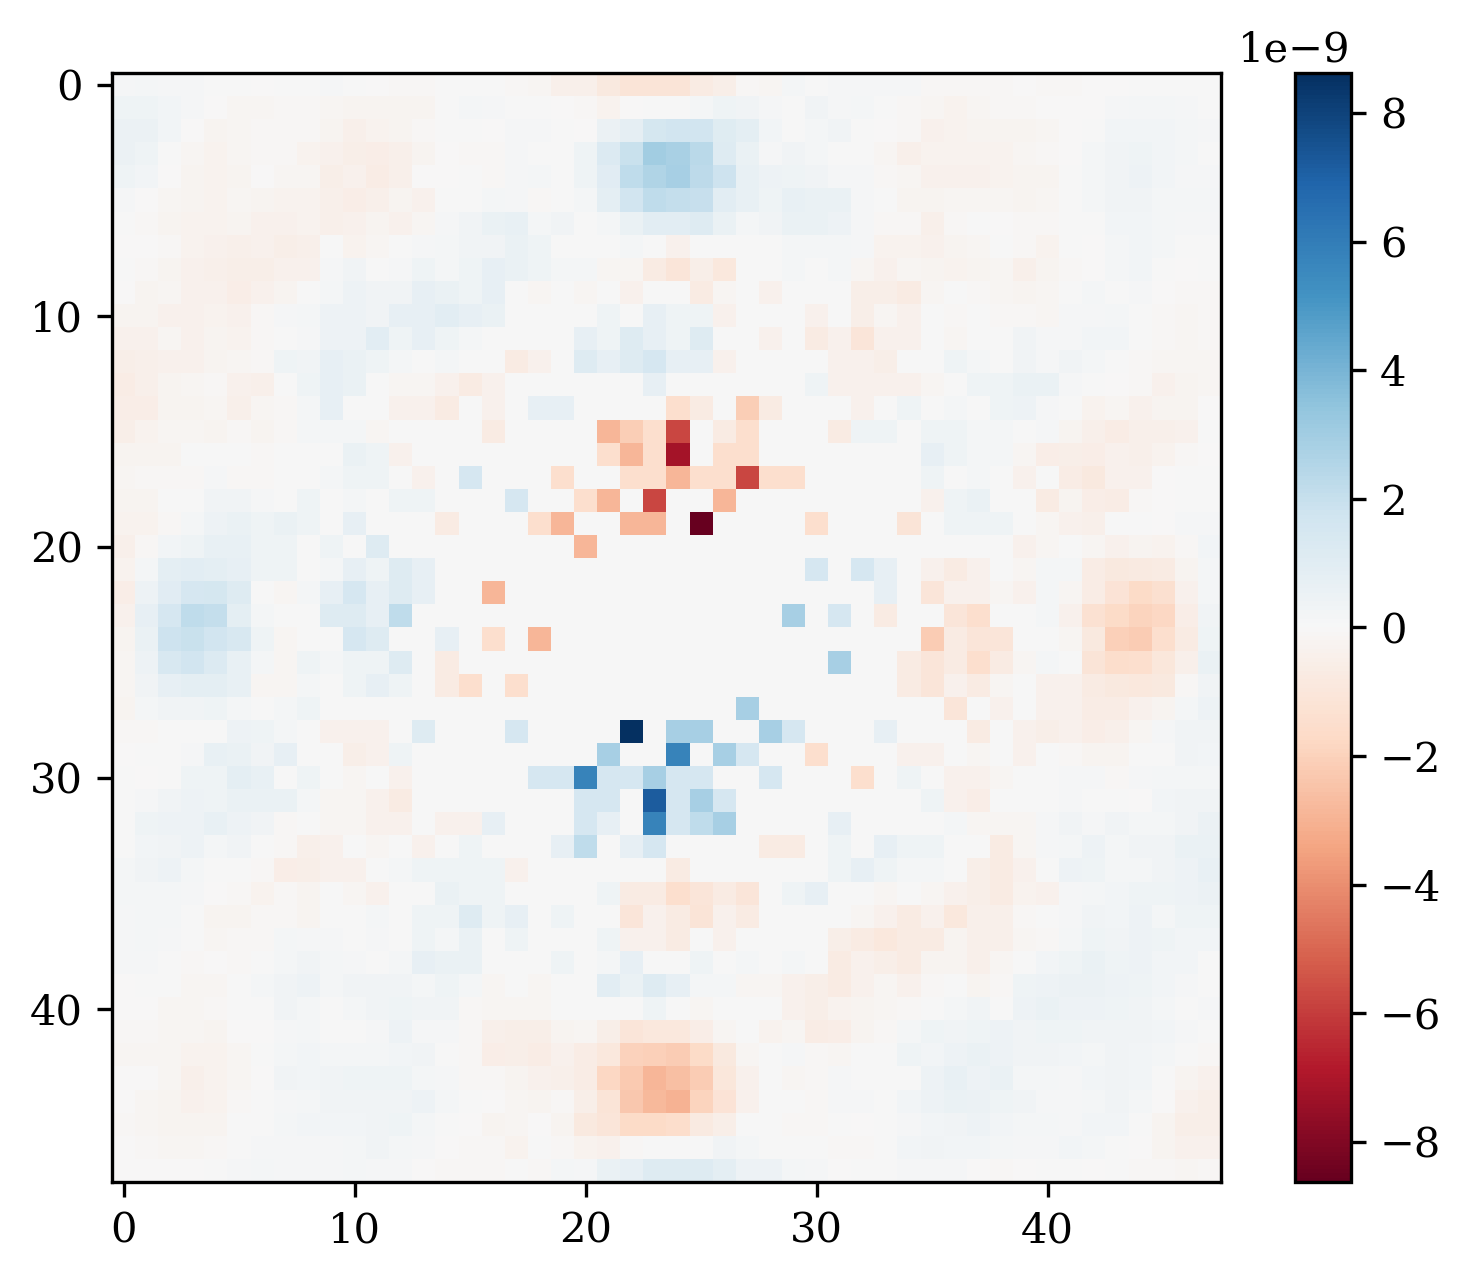

In [25]:
stacked_stacked_img = stacked_img + np.rot90(stacked_img)
stacked_stacked_img_rot90 = np.rot90(stacked_stacked_img)
diff_stacked_img_90 = stacked_stacked_img - stacked_stacked_img_rot90
plt.imshow(diff_stacked_img_90, cmap='RdBu', norm=colors.CenteredNorm())
plt.colorbar()
plt.savefig(join(fig_dir, stem, 'stacked_stacked_img_diff_90_small_10k_mirror_half.png'))
plt.show()

In [ ]:
stacked_img_gs = gs.Image(stacked_img)
stacked_img_rot90_gs = gs.Image(stacked_img_rot90)
img_gs = gs.Image(test_ds[0]['img'].numpy()[0])

In [ ]:
shape_data = gs.hsm.FindAdaptiveMom(stacked_img_gs)
shape_data_rot90 = gs.hsm.FindAdaptiveMom(stacked_img_rot90_gs)
shape_data_img = gs.hsm.FindAdaptiveMom(img_gs)

In [32]:
print(shape_data_rot90.observed_shape)
print(shape_data_rot90.moments_centroid)

galsim.Shear(g1=-0.0010777359079734905,g2=-0.001440276745030729)
galsim.PositionD(24.500000003732865,24.49999999948981)


In [33]:
print(shape_data.observed_shape)
print(shape_data.moments_centroid)

galsim.Shear(g1=-0.0016738436799049667,g2=-0.0008104319657234051)
galsim.PositionD(24.50000000060999,24.500000003714284)


In [124]:
print(shape_data_img.observed_shape)
print(shape_data_img.moments_centroid)

galsim.Shear(g1=-0.04475104975200912,g2=-0.05429728980469388)
galsim.PositionD(24.500000005653472,24.500000001559876)


In [126]:
print(test_ds[2]['fid_pars'])

tensor([ 0.2960,  0.6589, -0.5658,  0.1187, -0.9972,  0.1800,  0.9350, -0.4350],
       dtype=torch.float64)


In [8]:
samples = pd.read_csv('/ocean/projects/phy250048p/shared/samples/samples_g_sini_theta_even.csv')
# samples_sorted = samples.sort_values(by=['theta_int'])

In [12]:
samples['theta_int'][500:].mean()

3.637978807091713e-15

In [94]:
qz = 0.2
a = 1-qz**2
e_int = a*samples['sini']**2 / (2-a*samples['sini']**2)

In [95]:
gp, gc = img_to_gal_axis(samples['g1'], samples['g2'], samples['theta_int'])

In [96]:
e_obs = e_int + 2*gp*(1-e_int**2)
theta_obs = (gc/e_int - samples['theta_int']) % (2*np.pi)
theta_obs[theta_obs > np.pi] -= 2*np.pi

In [97]:
e1 = e_obs * np.cos(2*theta_obs)
e2 = e_obs * np.sin(2*theta_obs)

In [98]:
print(np.sum(e1), np.sum(e2))

-29.378006133515058 264.2111287714564


In [92]:
e_mag = np.sqrt(np.sum(e1**2) + np.sum(e2**2))
theta_e = 0.5 * np.arctan2(np.sum(e2), np.sum(e1))
print(theta_e)

0.7654303627891099


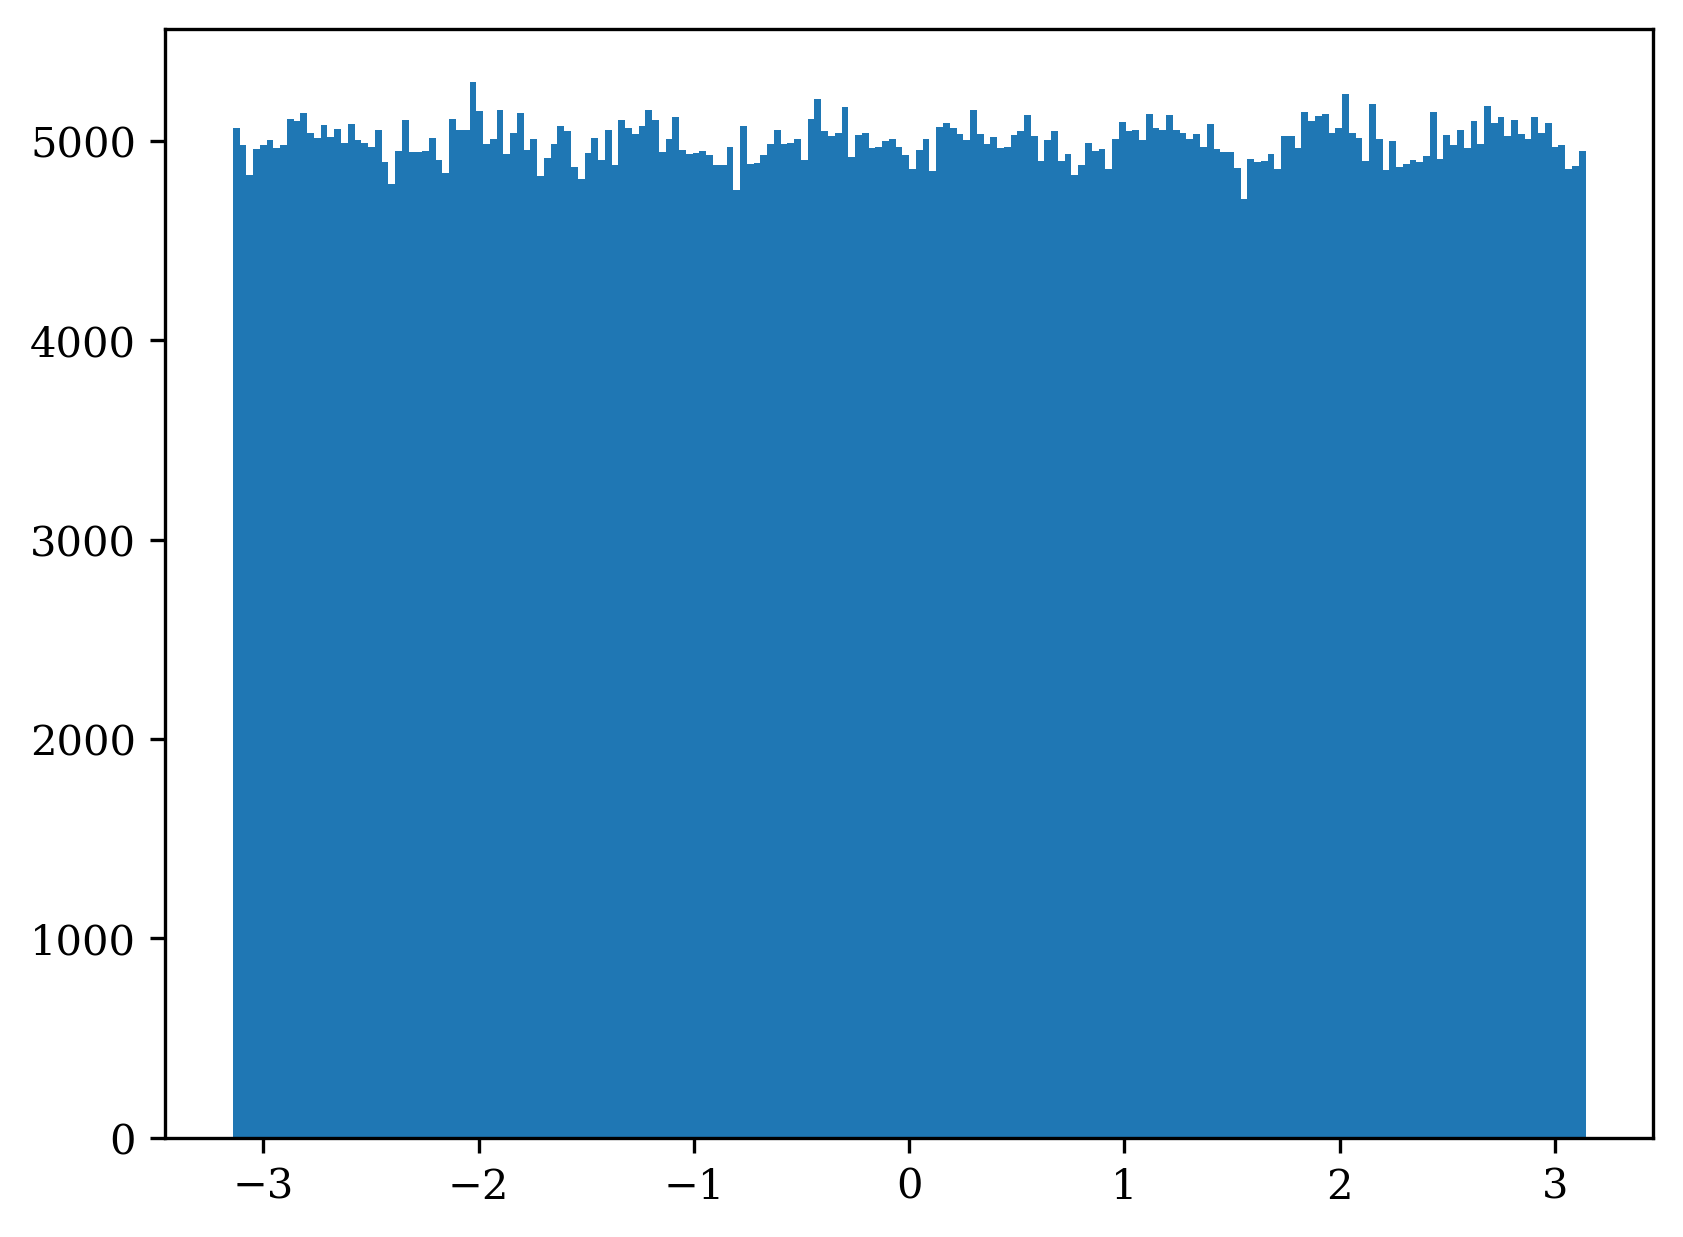

In [103]:
plt.hist(theta_obs, bins=200)
plt.savefig(join(fig_dir, stem, 'theta_obs_hist_train.png'))
plt.show()

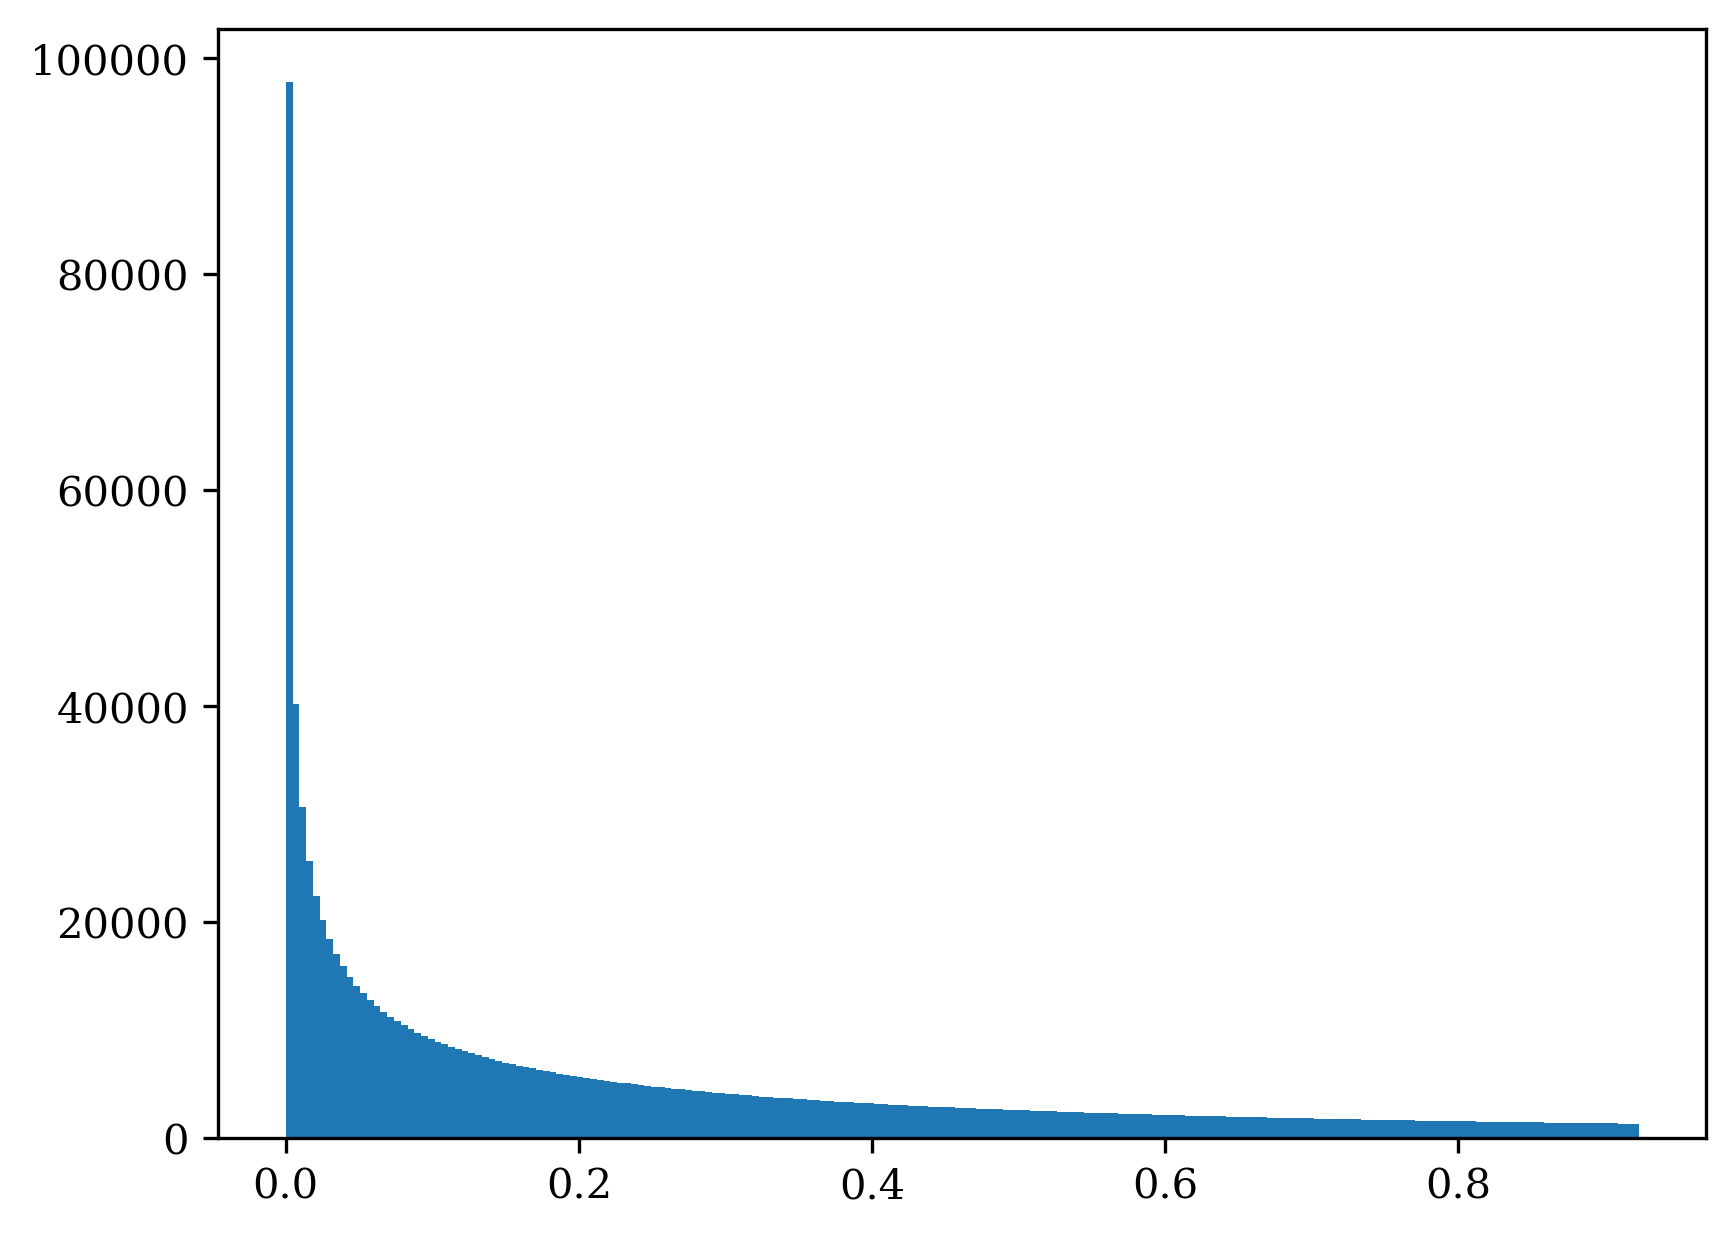

In [12]:
plt.hist(e_int, bins=200)
plt.show()

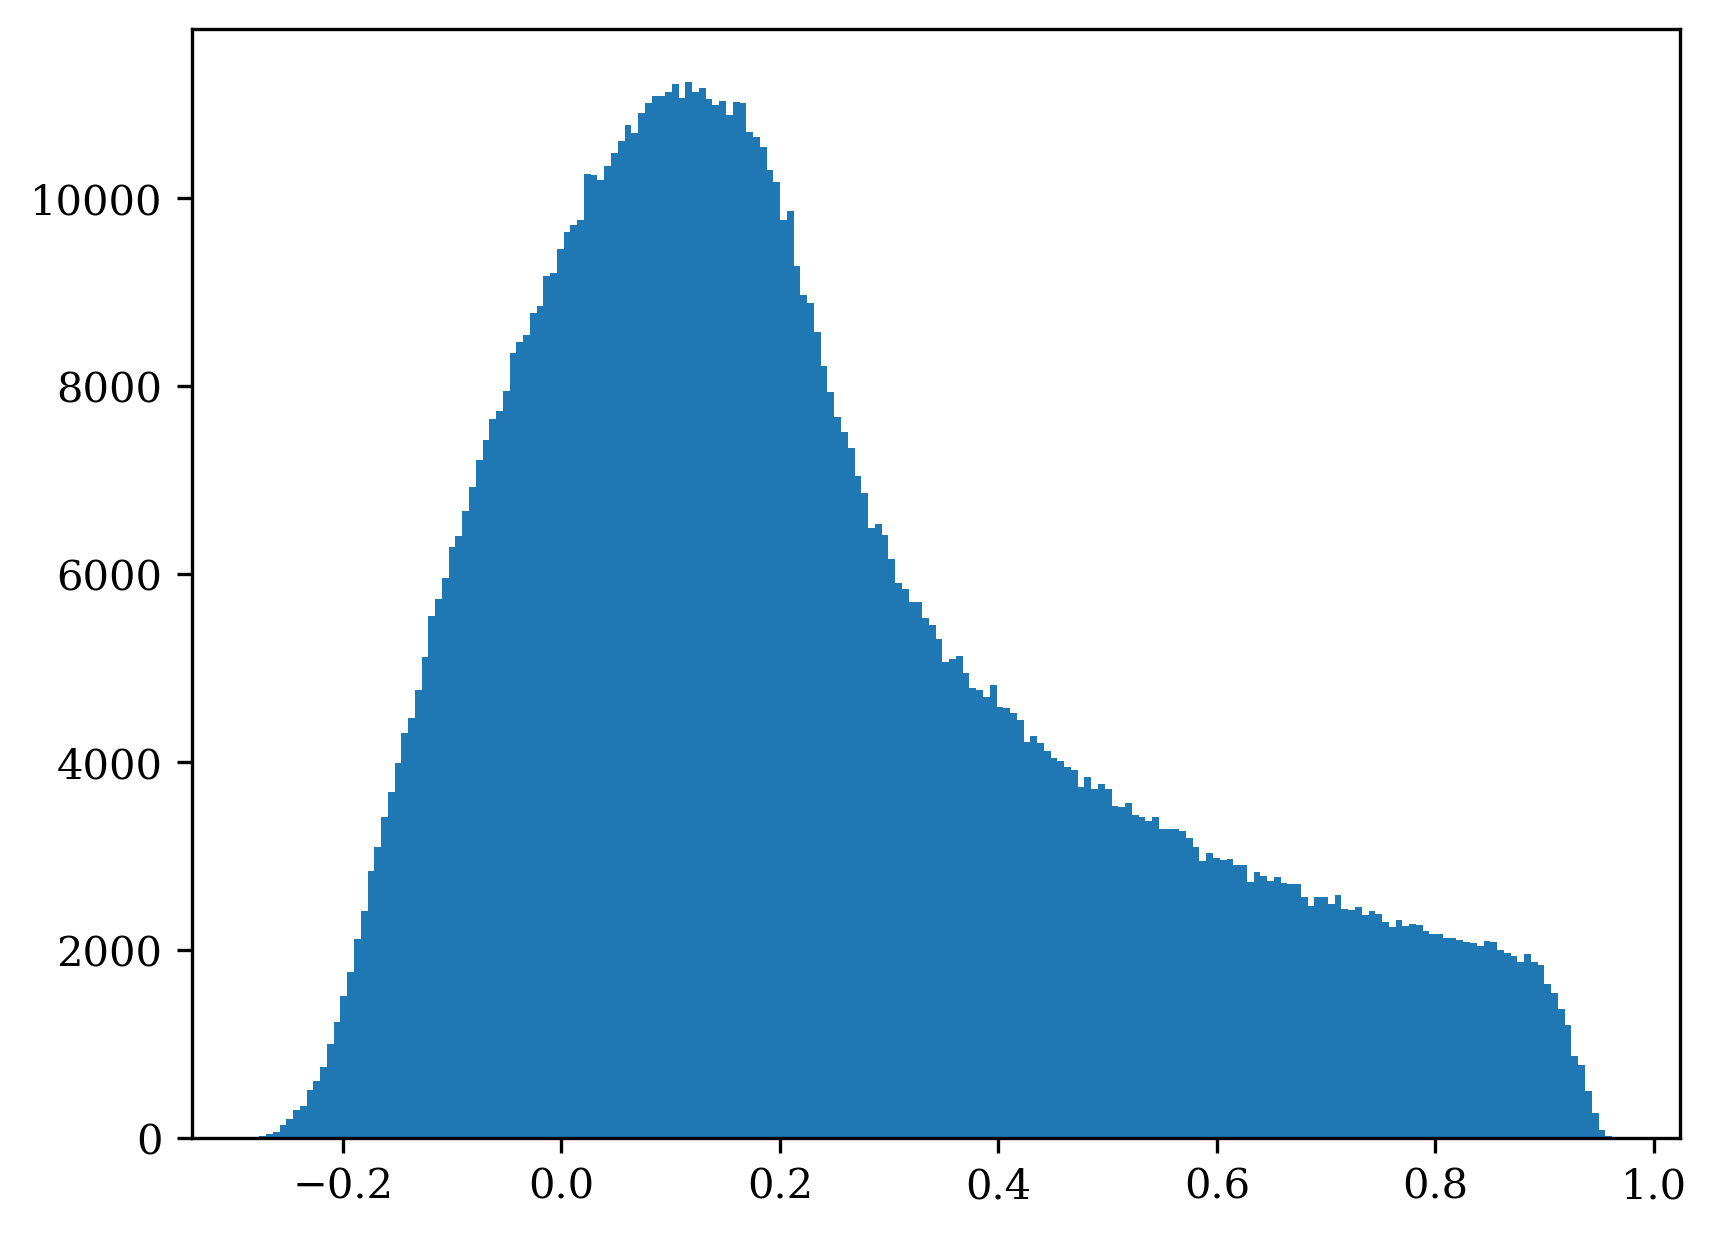

In [29]:
plt.hist(e_obs, bins=200)
plt.show()

In [20]:
print(samples_sorted.iloc[0]['theta_int'] + np.pi)
print(samples_sorted.iloc[1]['theta_int'] - samples_sorted.iloc[0]['theta_int'])
print(samples_sorted.iloc[2]['theta_int'] - samples_sorted.iloc[1]['theta_int'])

3.1415926535771632e-06
6.2831853071543264e-06
6.283185307598416e-06


In [18]:
# Jackknife resampling
# snrs = torch.rand((len(test_ds),), device=device)*995 + 5
snrs = torch.full((len(test_ds),), 1000., device=device)
n_jackknife = len(test_ds) // bs
jackknife_shapes = []
for i in range(n_jackknife):
    jackknife_img = torch.zeros_like(test_ds[0]['img'], device=device)
    for j, batch in enumerate(test_dl):
        if j == i:
            continue
        # jackknife_img += torch.sum(apply_noise(batch['img'].float().to(device), snrs[j], device=device), dim=0)
        jackknife_img += torch.sum(batch['img'].float().to(device), dim=0)
    jackknife_img = jackknife_img.cpu().numpy()[0]
    jackknife_img /= np.max(jackknife_img)
    
    jackknife_img_gs = gs.Image(jackknife_img)
    shape_data = gs.hsm.FindAdaptiveMom(jackknife_img_gs)
    jackknife_shapes.append(shape_data.observed_shape)

In [19]:
g1_arr = np.array([shape.g1 for shape in jackknife_shapes])
g2_arr = np.array([shape.g2 for shape in jackknife_shapes])
g1_mean = np.mean(g1_arr)
g2_mean = np.mean(g2_arr)
g1_var = (n_jackknife - 1) / n_jackknife * np.sum((g1_arr - g1_mean)**2)
g2_var = (n_jackknife - 1) / n_jackknife * np.sum((g2_arr - g2_mean)**2)

In [20]:
print("Stack test ellipticities:", g1_mean, g2_mean)
print("Stack test ellipticity variances:", g1_var, g2_var)

Stack test ellipticities: -0.0005482355450733415 5.676193230719218e-10
Stack test ellipticity variances: 0.0006240668950672524 0.0006184723681910775


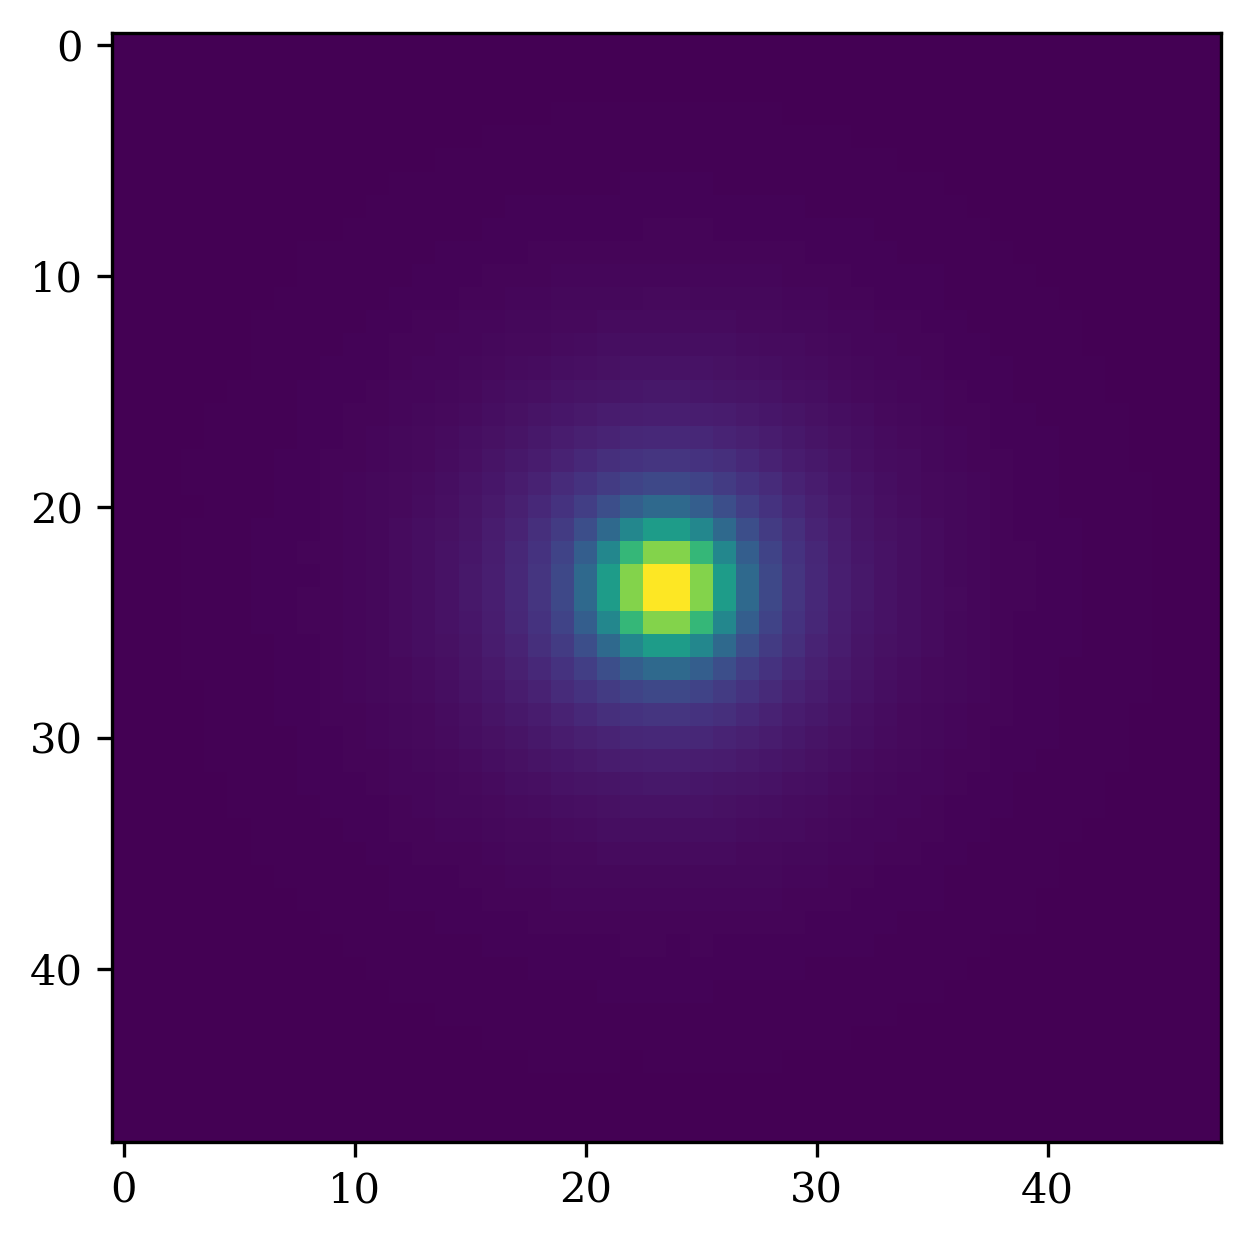

In [61]:
plt.imshow(stacked_img)